# Sentiment Analysis with DistilBERT

In this notebook, we implement a Transformer-based sentiment classifier using DistilBERT.

We train and evaluate the model on three different datasets:
- 1K Amazon Reviews
- 25K Amazon Reviews
- Video Game Reviews

Each dataset is processed and evaluated independently using the same pipeline.

## Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

from utils import device_check
from transformer_utils import (
    save_tf_run,
    build_tf_loaders,
    fit_tf,
    evaluate_tf,
    plot_confusion_matrix_tf,
)

device = device_check()

PyTorch: 2.11.0+cu130 | Python: 3.11.15 | OS: Linux 5.15.0-168-generic
CUDA available: True
GPUs: 1 x NVIDIA GeForce RTX 2080 Ti (11.3 GB)
CUDA: 13.0 | cuDNN: 91900
Using cuda / NVIDIA GeForce RTX 2080 Ti


In [2]:
LOG_WANDB = True
WANDB_DIR  = Path("..")
SPLITS_DIR = Path("../data/splits")

NUM_WORKERS = min(4, os.cpu_count() or 0)
# pin_memory is set by build_tf_loaders automatically
SEED = 1

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Make results reproducible
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

---
## Initial Test — 1K Amazon Reviews

### Load Pre-split Data

In [3]:
train_df = pd.read_csv(SPLITS_DIR / "1k_train.csv")
val_df = pd.read_csv(SPLITS_DIR / "1k_val.csv")
test_df = pd.read_csv(SPLITS_DIR / "1k_test.csv")

text_col = "Sentence"
label_col = "Class"

NUM_LABELS = 2
NUM_CLASSES = 2

### DataLoaders

We tokenize the text and build DataLoaders from the pre-split CSV files.

In [4]:
BATCH_SIZE = 32

loaders = build_tf_loaders(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    tokenizer=tokenizer,
    text_col=text_col,
    label_col=label_col,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

### Model

We fine-tune a pre-trained DistilBERT model for binary sentiment classification.

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)

model.to(device)

LEARNING_RATE = 2e-5

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Training

The model is trained on the training split and validated after every epoch. The best checkpoint is restored automatically based on validation loss.

In [6]:
NUM_EPOCHS = 5

total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)

wandb_kwargs = dict(
    entity='d7047e-group12',
    project='Lab1',
    name='DistilBERT 1K',
    tags=['Task 1.2', 'DistilBERT', 'Transformer', '1K'],
    dir=WANDB_DIR,
    config={
        'dataset': 'Amazon 1K',
        'model_name': MODEL_NAME,
        'optimizer': type(optimizer).__name__,
        'lr': LEARNING_RATE,
        'epochs': NUM_EPOCHS,
        'batch_size': BATCH_SIZE,
        'max_length': MAX_LENGTH,
        'warmup_ratio': 0.1,
    },
)

_ = fit_tf(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=NUM_EPOCHS,
    scheduler=scheduler,
    wandb_kwargs=wandb_kwargs,
    log=LOG_WANDB,
)

_ = save_tf_run(
    out_dir='../models/distilbert_1k',
    model=model,
    model_name=MODEL_NAME,
    num_labels=NUM_LABELS,
    max_length=MAX_LENGTH,
)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: oscar-engelmark (d7047e-group12) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch | Train Loss | Train Acc  | Val Loss   | Val Acc   
  1/5 |     0.6405 |     65.31% |     0.4203 |     95.56%
  2/5 |     0.2994 |     91.36% |     0.2167 |     92.22%
  3/5 |     0.1440 |     96.05% |     0.1749 |     92.22%
  4/5 |     0.0815 |     98.27% |     0.2109 |     91.11%
  5/5 |     0.0645 |     98.52% |     0.2105 |     91.11%

Restored best weights (val loss 0.1749)


Training Accuracy,▁▆▇██
Training Loss,█▄▂▁▁
Validation Accuracy,█▃▃▁▁
Validation Loss,█▂▁▂▂
Training Accuracy,98.51852
Training Loss,0.06452
Validation Accuracy,91.11111
Validation Loss,0.21045
test_accuracy,93
test_loss,0.21579
test_macro_f1,0.92994


BERT run saved to: ../models/distilbert_1k


### Test-Set Evaluation & Confusion Matrix

The final result is reported on the held-out test set for fair comparison with the other models.

In [7]:
_ = evaluate_tf(
    model,
    test_loader,
    criterion,
    label="DistilBERT-1K",
    class_names=["Negative", "Positive"],
)

Classification Report: DistilBERT-1K

              precision    recall  f1-score   support

    Negative      0.906     0.960     0.932        50
    Positive      0.957     0.900     0.928        50

    accuracy                          0.930       100
   macro avg      0.932     0.930     0.930       100
weighted avg      0.932     0.930     0.930       100



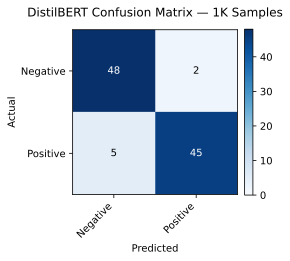

In [8]:
plot_confusion_matrix_tf(
    model,
    test_loader,
    NUM_CLASSES,
    ["Negative", "Positive"],
    "DistilBERT Confusion Matrix — 1K Samples"
)

---
## Scaling Up — 25K Amazon Reviews

### Load Pre-split Data

In [9]:
train_df = pd.read_csv(SPLITS_DIR / "25k_train.csv")
val_df = pd.read_csv(SPLITS_DIR / "25k_val.csv")
test_df = pd.read_csv(SPLITS_DIR / "25k_test.csv")

text_col = "Sentence"
label_col = "Class"

NUM_LABELS = 2
NUM_CLASSES = 2

### Tokenizer & DataLoaders

In [10]:
BATCH_SIZE = 32

loaders = build_tf_loaders(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    tokenizer=tokenizer,
    text_col=text_col,
    label_col=label_col,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

### Model

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)

model.to(device)

LEARNING_RATE = 2e-5

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Training

In [12]:
NUM_EPOCHS = 5

total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)

wandb_kwargs = dict(
    entity='d7047e-group12',
    project='Lab1',
    name='DistilBERT 25K',
    tags=['Task 1.2', 'DistilBERT', 'Transformer', '25K'],
    dir=WANDB_DIR,
    config={
        'dataset': 'Amazon 25K',
        'model_name': MODEL_NAME,
        'optimizer': type(optimizer).__name__,
        'lr': LEARNING_RATE,
        'epochs': NUM_EPOCHS,
        'batch_size': BATCH_SIZE,
        'max_length': MAX_LENGTH,
        'warmup_ratio': 0.1,
    },
)

_ = fit_tf(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=NUM_EPOCHS,
    scheduler=scheduler,
    wandb_kwargs=wandb_kwargs,
    log=LOG_WANDB,
)

_ = save_tf_run(
    out_dir='../models/distilbert_25k',
    model=model,
    model_name=MODEL_NAME,
    num_labels=NUM_LABELS,
    max_length=MAX_LENGTH,
)

Epoch | Train Loss | Train Acc  | Val Loss   | Val Acc   
  1/5 |     0.3136 |     84.92% |     0.2046 |     92.36%
  2/5 |     0.1654 |     94.16% |     0.2120 |     92.80%
  3/5 |     0.1047 |     96.80% |     0.2525 |     92.62%
  4/5 |     0.0678 |     98.20% |     0.3022 |     92.27%
  5/5 |     0.0491 |     98.87% |     0.3219 |     92.36%

Restored best weights (val loss 0.2046)


Training Accuracy,▁▆▇██
Training Loss,█▄▂▁▁
Validation Accuracy,▂█▆▁▂
Validation Loss,▁▁▄▇█
Training Accuracy,98.87407
Training Loss,0.04905
Validation Accuracy,92.35556
Validation Loss,0.32187
test_accuracy,92.48
test_loss,0.20177
test_macro_f1,0.92204


BERT run saved to: ../models/distilbert_25k


### Test-Set Evaluation & Confusion Matrix

In [13]:
_ = evaluate_tf(
    model,
    test_loader,
    criterion,
    label="DistilBERT-25K",
    class_names=["Negative", "Positive"],
)

Classification Report: DistilBERT-25K

              precision    recall  f1-score   support

    Negative      0.884     0.932     0.907       988
    Positive      0.954     0.920     0.937      1512

    accuracy                          0.925      2500
   macro avg      0.919     0.926     0.922      2500
weighted avg      0.926     0.925     0.925      2500



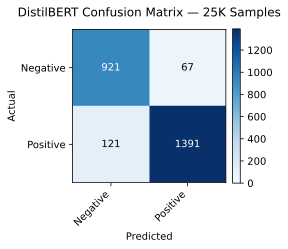

In [14]:
plot_confusion_matrix_tf(
    model,
    test_loader,
    NUM_CLASSES,
    ["Negative", "Positive"],
    "DistilBERT Confusion Matrix — 25K Samples"
)

---
## Video Game Reviews — 5-Class Rating

### Load Pre-split Data

In [15]:
train_df = pd.read_csv(SPLITS_DIR / "vg_train.csv")
val_df = pd.read_csv(SPLITS_DIR / "vg_val.csv")
test_df = pd.read_csv(SPLITS_DIR / "vg_test.csv")

text_col = "Sentence"
label_col = "Class"

# Convert labels from 1-5 → 0-4
train_df[label_col] = train_df[label_col].astype(int) - 1
val_df[label_col] = val_df[label_col].astype(int) - 1
test_df[label_col] = test_df[label_col].astype(int) - 1

NUM_LABELS = 5
NUM_CLASSES = 5

### Tokenizer & DataLoaders

In [16]:
BATCH_SIZE = 32

loaders = build_tf_loaders(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    tokenizer=tokenizer,
    text_col=text_col,
    label_col=label_col,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

### Model

In [17]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)

model.to(device)

LEARNING_RATE = 2e-5
LABEL_SMOOTHING = 0.1

# Inverse-frequency class weights to counter the ~58% 5-star imbalance
class_counts = np.bincount(np.asarray(train_df[label_col], dtype=np.int64))
class_weights = torch.tensor(
    (1.0 / class_counts) / (1.0 / class_counts).sum() * len(class_counts),
    dtype=torch.float, device=device,
)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Training

In [18]:
NUM_EPOCHS = 5

total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)

wandb_kwargs = dict(
    entity='d7047e-group12',
    project='Lab1',
    name='DistilBERT VG',
    tags=['Task 1.2', 'DistilBERT', 'Transformer', 'VG'],
    dir=WANDB_DIR,
    config={
        'dataset': 'Video Games',
        'model_name': MODEL_NAME,
        'optimizer': type(optimizer).__name__,
        'lr': LEARNING_RATE,
        'epochs': NUM_EPOCHS,
        'batch_size': BATCH_SIZE,
        'max_length': MAX_LENGTH,
        'warmup_ratio': 0.1,
        'label_smoothing': LABEL_SMOOTHING,
        'class_weights': class_weights.tolist(),
    },
)

_ = fit_tf(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=NUM_EPOCHS,
    scheduler=scheduler,
    wandb_kwargs=wandb_kwargs,
    log=LOG_WANDB,
)

_ = save_tf_run(
    out_dir='../models/distilbert_vg',
    model=model,
    model_name=MODEL_NAME,
    num_labels=NUM_LABELS,
    max_length=MAX_LENGTH,
)

Epoch | Train Loss | Train Acc  | Val Loss   | Val Acc   


Traceback (most recent call last):
  File "/root/D7047E/Lab1/src/transformer_utils.py", line 314, in fit_tf
    train_loss, train_acc = train_tf(model, train_loader, optimizer, criterion, scheduler, scaler)
                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/root/D7047E/Lab1/src/transformer_utils.py", line 191, in train_tf
    scaler.scale(loss).backward()
  File "/usr/local/lib/python3.11/dist-packages/torch/_tensor.py", line 631, in backward
    torch.autograd.backward(
  File "/usr/local/lib/python3.11/dist-packages/torch/autograd/__init__.py", line 381, in backward
    _engine_run_backward(
  File "/usr/local/lib/python3.11/dist-packages/torch/autograd/graph.py", line 869, in _engine_run_backward
    return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

### Test-Set Evaluation & Confusion Matrix

In [ ]:
_ = evaluate_tf(
    model,
    test_loader,
    criterion,
    label="DistilBERT-VG",
    class_names=['1-star', '2-star', '3-star', '4-star', '5-star'],
)

In [ ]:
plot_confusion_matrix_tf(
    model,
    test_loader,
    NUM_CLASSES,
    class_names=['1-star', '2-star', '3-star', '4-star', '5-star'],
    "DistilBERT Confusion Matrix — Video Game Reviews",
    normalize=True,
)